<a href="https://www.kaggle.com/code/cmdcrypto/pretrained?scriptVersionId=333060693" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import os
path = "/kaggle/input/datasets/harshjaglan01/image-classification-by-cnn/flowers"
print(os.listdir(path))

['dandelion', 'daisy', 'sunflower', 'tulip', 'rose']


In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Dropout,BatchNormalization,Conv2D,MaxPooling2D,Flatten,GlobalAveragePooling2D, Lambda

In [4]:
train_ds = keras.utils.image_dataset_from_directory(
    directory = "/kaggle/input/datasets/harshjaglan01/image-classification-by-cnn/flowers",
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=123,
    validation_split=0.2,
    subset="training",
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)
validation_ds = keras.utils.image_dataset_from_directory(
    directory = "/kaggle/input/datasets/harshjaglan01/image-classification-by-cnn/flowers",
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=123,
    validation_split=0.2,
    subset="validation",
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)

val_batches = tf.data.experimental.cardinality(validation_ds)
test_ds = validation_ds.take(val_batches // 2)
validation_ds = validation_ds.skip(val_batches // 2)

Found 4317 files belonging to 5 classes.
Using 3454 files for training.


I0000 00:00:1783324095.818132      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 4317 files belonging to 5 classes.
Using 863 files for validation.


In [5]:
train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [6]:
from tensorflow.keras.applications import InceptionResNetV2

base_model = InceptionResNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(256,256,3),
    name="inception_resnet_v2",
)


219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [7]:
preprocess_input = tf.keras.applications.inception_resnet_v2.preprocess_input
model = Sequential()
model.add(Lambda(preprocess_input))
model.add(base_model)
model.add(GlobalAveragePooling2D())
model.add(Dense(256,activation="relu",kernel_initializer="he_uniform"))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(128,activation="relu",kernel_initializer="he_uniform"))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(64,activation="relu",kernel_initializer="he_uniform"))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(5,activation="softmax"))

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_resnet_v2             │ (None, 6, 6, 1536)     │    54,336,736 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_203         │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_204         │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_205         │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,336,736 (207.28 MB)

 Trainable params: 54,276,192 (207.05 MB)

 Non-trainable params: 60,544 (236.50 KB)

In [8]:
base_model.trainable = False

In [9]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [10]:
history = model.fit(train_ds,epochs=20,validation_data=validation_ds)

Epoch 1/20
  1/108 ━━━━━━━━━━━━━━━━━━━━ 59:36 33s/step - accuracy: 0.2812 - loss: 2.4300

I0000 00:00:1783324137.985138      76 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


108/108 ━━━━━━━━━━━━━━━━━━━━ 81s 447ms/step - accuracy: 0.5692 - loss: 1.2687 - val_accuracy: 0.7606 - val_loss: 0.6383
Epoch 2/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 14s 127ms/step - accuracy: 0.7145 - loss: 0.7780 - val_accuracy: 0.8479 - val_loss: 0.4415
Epoch 3/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 14s 127ms/step - accuracy: 0.7626 - loss: 0.6799 - val_accuracy: 0.8456 - val_loss: 0.4109
Epoch 4/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 14s 127ms/step - accuracy: 0.7947 - loss: 0.5807 - val_accuracy: 0.8635 - val_loss: 0.3751
Epoch 5/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 14s 127ms/step - accuracy: 0.8118 - loss: 0.5287 - val_accuracy: 0.8702 - val_loss: 0.3706
Epoch 6/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 14s 127ms/step - accuracy: 0.8312 - loss: 0.4918 - val_accuracy: 0.8725 - val_loss: 0.3582
Epoch 7/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 14s 127ms/step - accuracy: 0.8445 - loss: 0.4460 - val_accuracy: 0.8881 - val_loss: 0.3451
Epoch 8/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 14s 127ms/step - accuracy: 0.8303 - loss: 0.4637 - val

<function matplotlib.pyplot.show(close=None, block=None)>

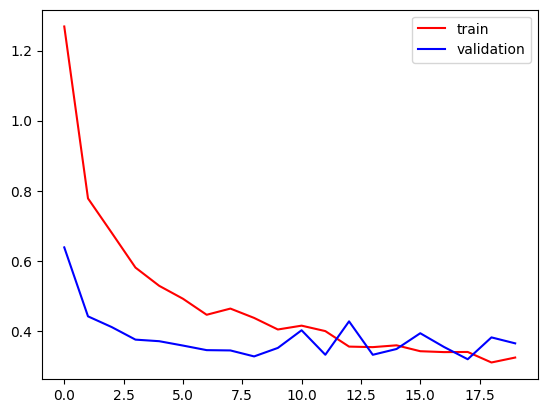

In [11]:
import matplotlib.pyplot as plt
plt.plot(history.history["loss"],color="red",label="train")
plt.plot(history.history["val_loss"],color="blue",label="validation")
plt.legend()
plt.show

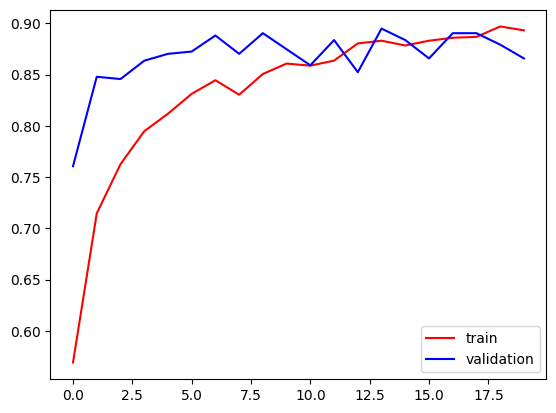

In [12]:
plt.plot(history.history["accuracy"],color="red",label="train")
plt.plot(history.history["val_accuracy"],color="blue",label="validation")
plt.legend()
plt.show()

In [13]:
prediction = model.evaluate(test_ds)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.8774 - loss: 0.3353


In [14]:
print(test_ds)
print(train_ds)

<_TakeDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
